In [1]:
!pip install --q sentence-transformers
!pip install --q deep-translator

In [71]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import pandas as pd
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
from deep_translator import GoogleTranslator
import openpyxl
import numpy as np

translator = GoogleTranslator(source="auto", target="en")

pd.reset_option('display')


# Ensuring Quality Standards

In [3]:
combined_df = pd.read_csv('FINAL_REDDIT_DATA.csv')
yes_count = (combined_df["Philippine Context?"] == "Yes").sum()
total = len(combined_df)

percentage = (yes_count / total) * 100
print(f"{percentage:.2f}%")

66.96%


At least 30% of entries should are from Philippine-focused subreddits (r/Philippines, r/phcareers, r/OFW). 

In [4]:
combined_df["Theme Tag"].value_counts()

Theme Tag
Ghosting                        114
Complex\nApplication Process    100
Job Search\nBurnout              97
Confusing\nUX                    77
Lack of\nRelevance               53
Possibility\nof Scam             43
Lack of\nVisibility              38
Other                            22
Overseas\nExperience             19
Name: count, dtype: int64

At least 5 different Theme Tags are represented

In [5]:
combined_df["Source Subreddit"].value_counts()

Source Subreddit
phcareers           219
r/phcareers          91
r/freelance          66
r/OFWs               38
r/jobs               35
r/recruitinghell     35
r/jobsearchhacks     35
r/Philippines        29
r/careerguidance     15
Name: count, dtype: int64

# Converting the Content to English

In [6]:
def translate_to_english(text):
    try:
        if pd.isna(text) or str(text).strip() == "":
            return text
        return translator.translate(str(text))
    except Exception:
        return text

In [8]:
combined_df["Content (English)"] = combined_df["Content (Full Text)"].apply(translate_to_english)

# # of K

In [113]:
model = SentenceTransformer("all-MiniLM-L6-v2")

In [126]:
def evaluate_k(df, theme, k_range=range(2, 9), model=model):
    subset = df[df["Theme Tag"] == theme].copy()
    print(subset.shape)
    texts = subset["Content (English)"].fillna("").tolist()

    if len(texts) < 10:
        print(f"Not enough data for {theme}")
        return

    embeddings = model.encode(texts, show_progress_bar=False)
    embeddings = normalize(embeddings)

    results = []

    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
        labels = kmeans.fit_predict(embeddings)

        if len(set(labels)) < 2:
            continue

        results.append({
            "k": k,
            "silhouette": silhouette_score(embeddings, labels),
            "davies_bouldin": davies_bouldin_score(embeddings, labels),
            "calinski_harabasz": calinski_harabasz_score(embeddings, labels),
            "inertia": kmeans.inertia_
        })

    results_df = pd.DataFrame(results)

    print(f"\n===== {theme} =====")
    print(results_df)

    # ---- plotting all metrics ----
    fig, axs = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(f"{theme} - Clustering Evaluation Metrics")

    axs[0, 0].plot(results_df["k"], results_df["inertia"], marker="o")
    axs[0, 0].set_title("Inertia (Elbow)")
    axs[0, 0].set_xlabel("k")

    axs[0, 1].plot(results_df["k"], results_df["silhouette"], marker="o")
    axs[0, 1].set_title("Silhouette Score (higher is better)")
    axs[0, 1].set_xlabel("k")

    axs[1, 0].plot(results_df["k"], results_df["davies_bouldin"], marker="o")
    axs[1, 0].set_title("Davies-Bouldin (lower is better)")
    axs[1, 0].set_xlabel("k")

    axs[1, 1].plot(results_df["k"], results_df["calinski_harabasz"], marker="o")
    axs[1, 1].set_title("Calinski-Harabasz (higher is better)")
    axs[1, 1].set_xlabel("k")

    plt.tight_layout()
    plt.show()

    return results_df

In [127]:
platform_df = combined_df[combined_df['Platform Mentioned'].notna()]
no_platform_df = combined_df[~combined_df['Platform Mentioned'].notna()]

(16, 14)

===== Ghosting =====
   k  silhouette  davies_bouldin  calinski_harabasz   inertia
0  2    0.047756        2.489437           1.952291  8.421285
1  3   -0.019836        2.410438           1.160027  8.142475
2  4   -0.013656        1.855879           1.285336  7.262076
3  5    0.024012        1.566264           1.561502  6.120367
4  6    0.013121        1.332717           1.502471  5.479348
5  7    0.020373        1.172924           1.649432  4.570171
6  8    0.001090        1.287261           1.383053  4.341576


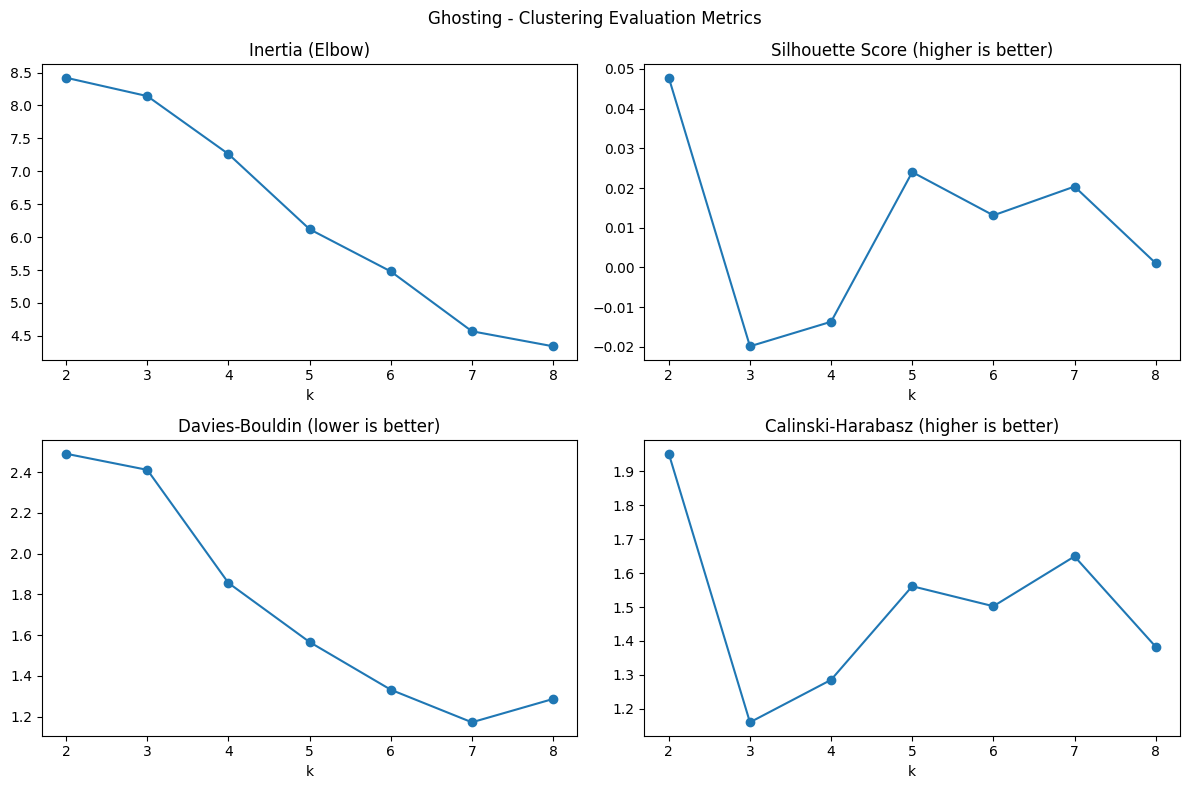

(98, 14)

===== Ghosting =====
   k  silhouette  davies_bouldin  calinski_harabasz    inertia
0  2    0.045059        4.078421           5.481101  64.215439
1  3    0.032955        4.258408           4.301996  62.244431
2  4    0.033622        3.670462           3.747983  60.629517
3  5    0.037424        3.420625           3.637809  58.697678
4  6    0.039126        3.061715           3.417314  57.249268
5  7    0.045928        2.845453           3.690526  54.596714
6  8    0.030036        3.045774           3.156328  54.501999


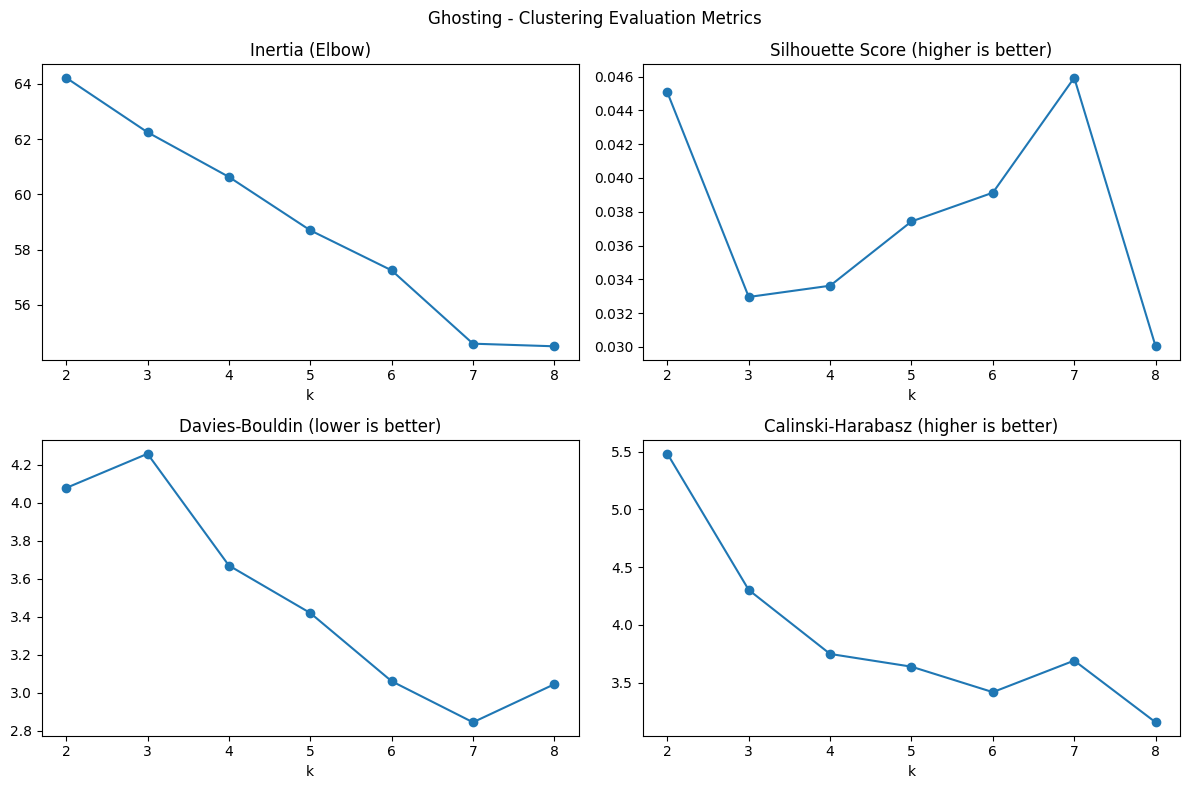

,k,silhouette,davies_bouldin,calinski_harabasz,inertia
0,2,0.045059,4.078421,5.481101,64.215439
1,3,0.032955,4.258408,4.301996,62.244431
2,4,0.033622,3.670462,3.747983,60.629517
3,5,0.037424,3.420625,3.637809,58.697678
4,6,0.039126,3.061715,3.417314,57.249268
5,7,0.045928,2.845453,3.690526,54.596714
6,8,0.030036,3.045774,3.156328,54.501999


In [129]:
evaluate_k(platform_df, "Ghosting")
evaluate_k(no_platform_df, "Ghosting")

# Process

In [130]:
platform_df['Theme Tag'].value_counts()

Theme Tag
Confusing\nUX                   25
Possibility\nof Scam            20
Ghosting                        16
Job Search\nBurnout             12
Lack of\nVisibility             10
Lack of\nRelevance               7
Complex\nApplication Process     7
Overseas\nExperience             4
Other                            2
Name: count, dtype: int64

(7, 14)
Not enough data for Complex
Application Process
(93, 14)

===== Complex
Application Process =====
   k  silhouette  davies_bouldin  calinski_harabasz    inertia
0  2    0.052564        3.876128           5.970110  68.299400
1  3    0.044302        3.881535           4.380468  66.323997
2  4    0.037743        3.569870           4.154192  63.840679
3  5    0.033264        3.413730           3.640773  62.446045
4  6    0.029259        3.263396           3.360266  60.999981
5  7    0.029821        3.190642           3.047873  60.017879
6  8    0.045921        2.796024           3.353400  57.030533


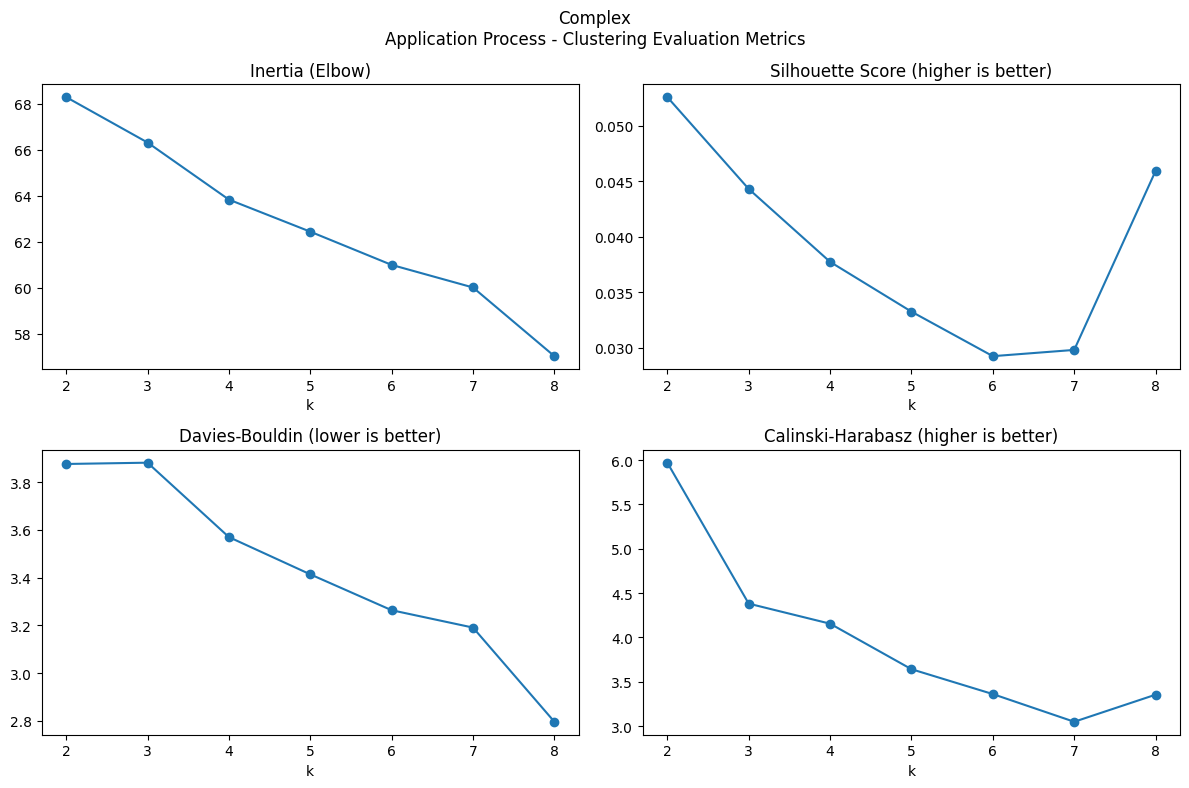

,k,silhouette,davies_bouldin,calinski_harabasz,inertia
0,2,0.052564,3.876128,5.970110,68.299400
1,3,0.044302,3.881535,4.380468,66.323997
2,4,0.037743,3.569870,4.154192,63.840679
3,5,0.033264,3.413730,3.640773,62.446045
4,6,0.029259,3.263396,3.360266,60.999981
5,7,0.029821,3.190642,3.047873,60.017879
6,8,0.045921,2.796024,3.353400,57.030533


In [136]:
evaluate_k(platform_df, "Complex\nApplication Process")
evaluate_k(no_platform_df, "Complex\nApplication Process")

# UX

(25, 14)

===== Confusing
UX =====
   k  silhouette  davies_bouldin  calinski_harabasz    inertia
0  2    0.043795        3.110475           2.269974  14.183144
1  3    0.021707        3.025118           1.745079  13.449298
2  4    0.036531        2.374706           1.802379  12.392172
3  5    0.044534        2.103537           1.948634  11.212954
4  6    0.038658        1.786958           1.856598  10.468338
5  7    0.042903        1.656342           1.847204   9.644494
6  8    0.033811        1.431299           1.761315   9.032293


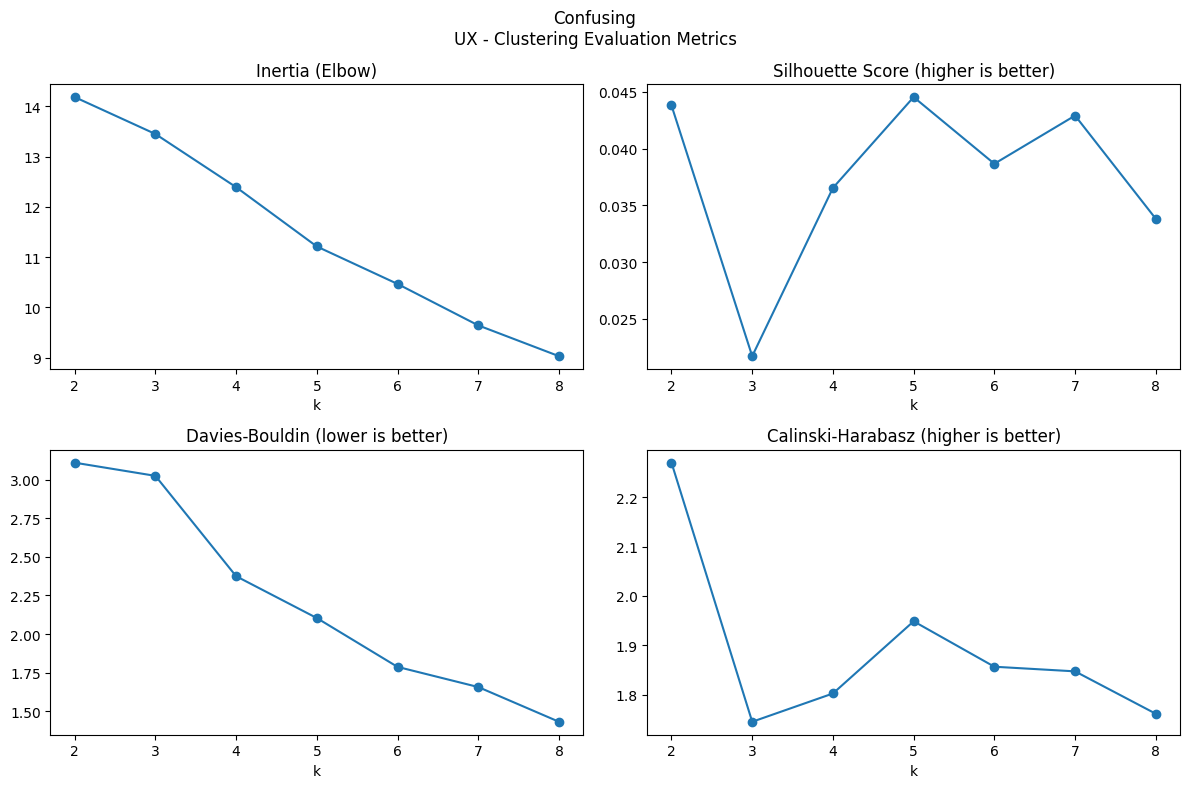

,k,silhouette,davies_bouldin,calinski_harabasz,inertia
0,2,0.043795,3.110475,2.269974,14.183144
1,3,0.021707,3.025118,1.745079,13.449298
2,4,0.036531,2.374706,1.802379,12.392172
3,5,0.044534,2.103537,1.948634,11.212954
4,6,0.038658,1.786958,1.856598,10.468338
5,7,0.042903,1.656342,1.847204,9.644494
6,8,0.033811,1.431299,1.761315,9.032293


In [137]:
evaluate_k(platform_df, "Confusing\nUX")

(52, 14)

===== Confusing
UX =====
   k  silhouette  davies_bouldin  calinski_harabasz    inertia
0  2    0.028362        4.513273           2.387928  36.887962
1  3    0.038466        3.352748           2.958308  34.485630
2  4    0.024444        3.120326           2.588955  33.266792
3  5    0.018318        3.083397           2.420274  32.048340
4  6    0.028915        2.831971           2.462776  30.488201
5  7    0.015908        2.780280           2.224680  29.807930
6  8    0.020135        2.396157           2.088294  29.011295


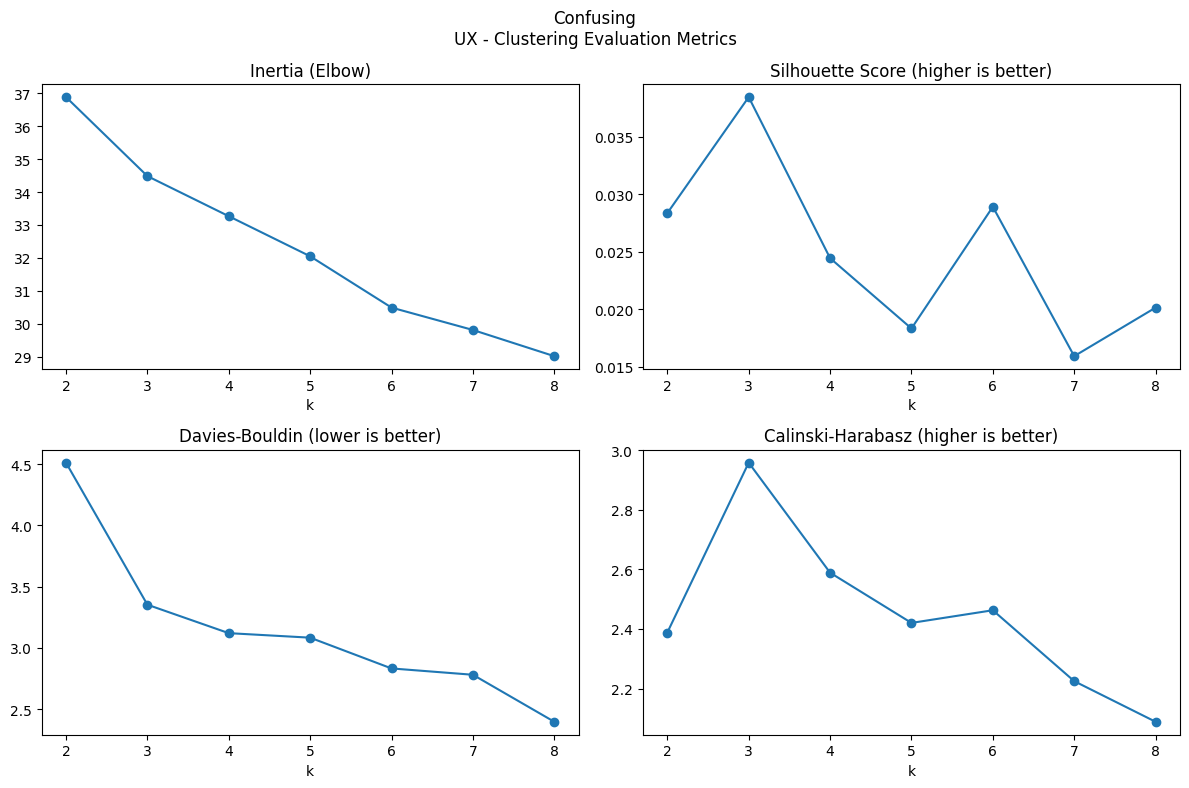

,k,silhouette,davies_bouldin,calinski_harabasz,inertia
0,2,0.028362,4.513273,2.387928,36.887962
1,3,0.038466,3.352748,2.958308,34.485630
2,4,0.024444,3.120326,2.588955,33.266792
3,5,0.018318,3.083397,2.420274,32.048340
4,6,0.028915,2.831971,2.462776,30.488201
5,7,0.015908,2.780280,2.224680,29.807930
6,8,0.020135,2.396157,2.088294,29.011295


In [133]:
evaluate_k(no_platform_df, "Confusing\nUX")

# EMOTIONAL (Job Search Burnout)

(12, 14)

===== Job Search
Burnout =====
   k  silhouette  davies_bouldin  calinski_harabasz   inertia
0  2    0.021206        2.738695           1.169687  5.751875
1  3    0.093728        1.679727           1.888030  4.525807
2  4    0.021185        1.582418           1.474177  4.137428
3  5    0.018052        1.360601           1.463677  3.498535
4  6    0.003374        1.203550           1.417080  2.945878
5  7    0.015816        1.025370           1.593797  2.205851
6  8    0.012188        0.789890           1.667712  1.639574


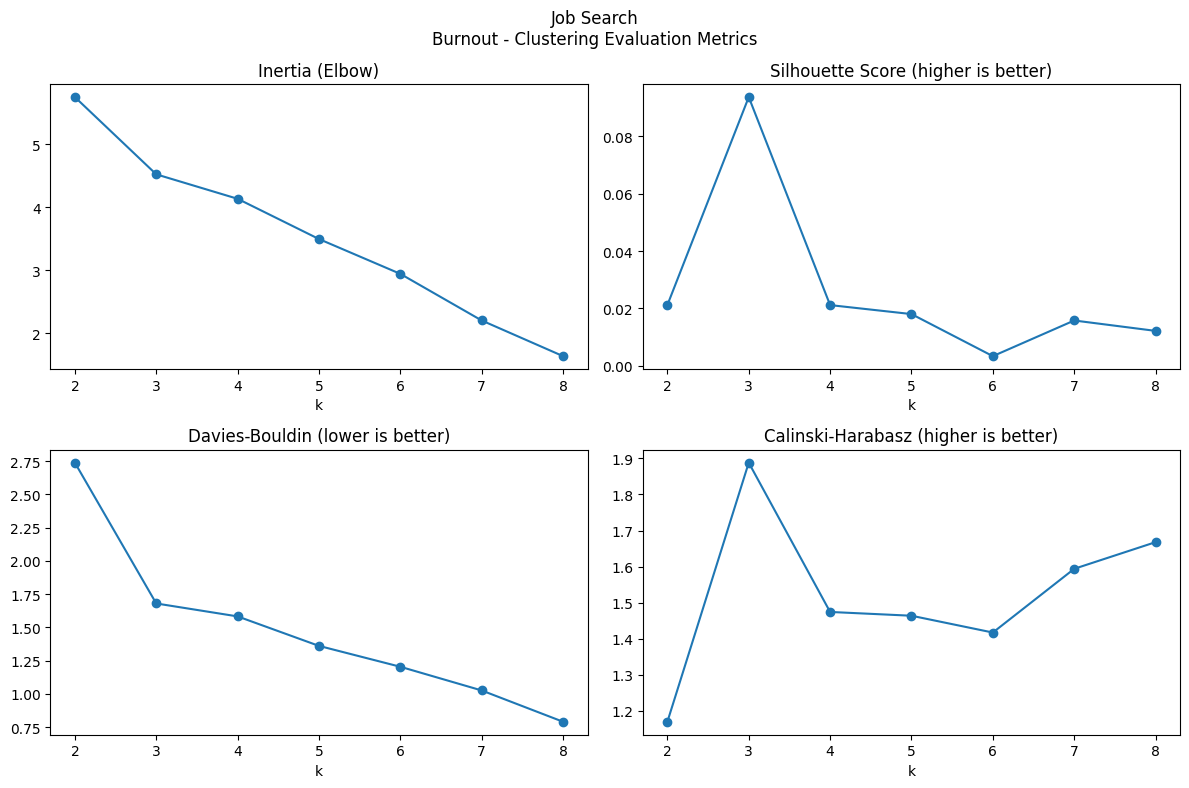

(85, 14)

===== Job Search
Burnout =====
   k  silhouette  davies_bouldin  calinski_harabasz    inertia
0  2    0.118397        2.661582           3.126538  55.800724
1  3    0.034556        3.818914           3.333875  53.548447
2  4    0.035073        3.237500           3.737033  50.862831
3  5    0.029722        3.390603           2.991284  50.369255
4  6    0.023121        3.162428           2.663228  49.550518
5  7    0.030674        2.875030           2.884234  47.388809
6  8    0.028068        2.933968           2.845810  46.001610


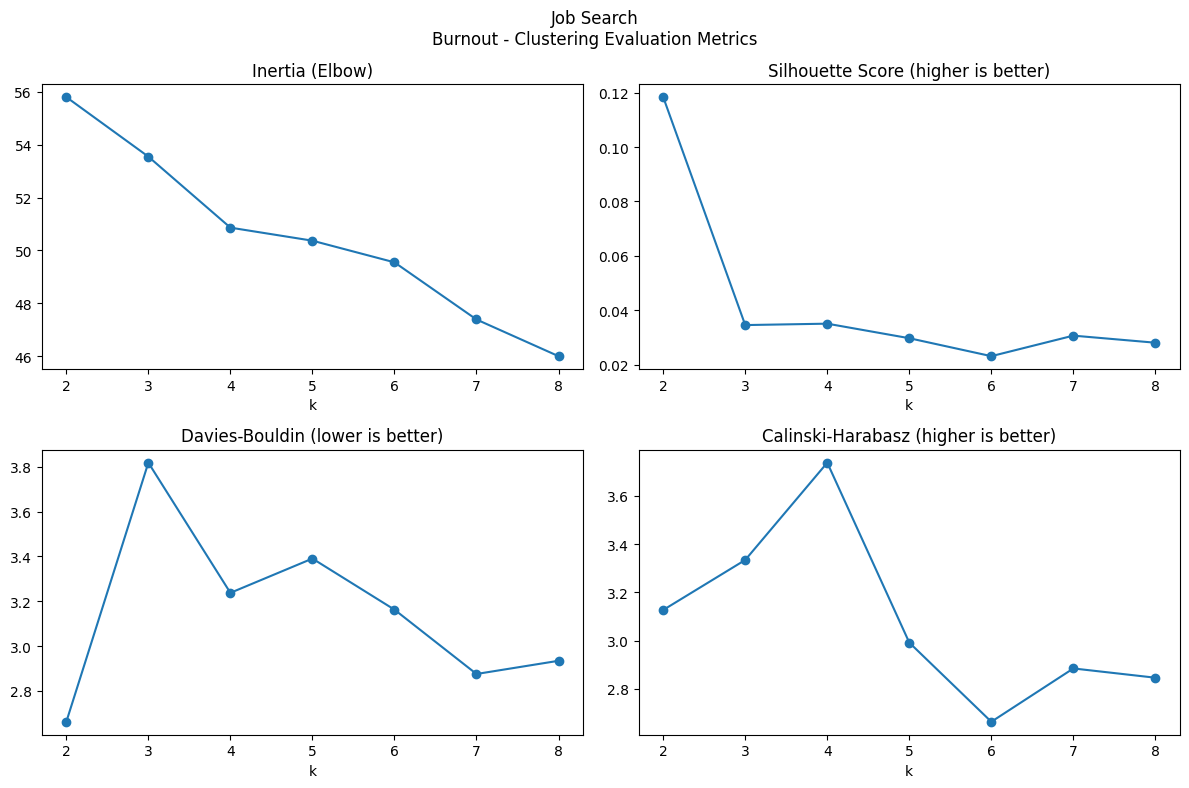

,k,silhouette,davies_bouldin,calinski_harabasz,inertia
0,2,0.118397,2.661582,3.126538,55.800724
1,3,0.034556,3.818914,3.333875,53.548447
2,4,0.035073,3.237500,3.737033,50.862831
3,5,0.029722,3.390603,2.991284,50.369255
4,6,0.023121,3.162428,2.663228,49.550518
5,7,0.030674,2.875030,2.884234,47.388809
6,8,0.028068,2.933968,2.845810,46.001610


In [138]:
evaluate_k(platform_df, "Job Search\nBurnout")
evaluate_k(no_platform_df, "Job Search\nBurnout")

# Lack of Relevance (RELAVANCE)

(7, 14)
Not enough data for Lack of
Relevance
(46, 14)

===== Lack of
Relevance =====
   k  silhouette  davies_bouldin  calinski_harabasz    inertia
0  2    0.061514        3.291985           2.322216  33.053871
1  3    0.030570        3.538104           2.595232  31.050339
2  4    0.036210        3.024641           2.489543  29.544621
3  5    0.036591        2.789464           2.309859  28.398678
4  6    0.036272        2.434244           2.142651  27.447165
5  7    0.025613        2.445335           1.975029  26.688931
6  8    0.027648        2.334367           1.988790  25.468014


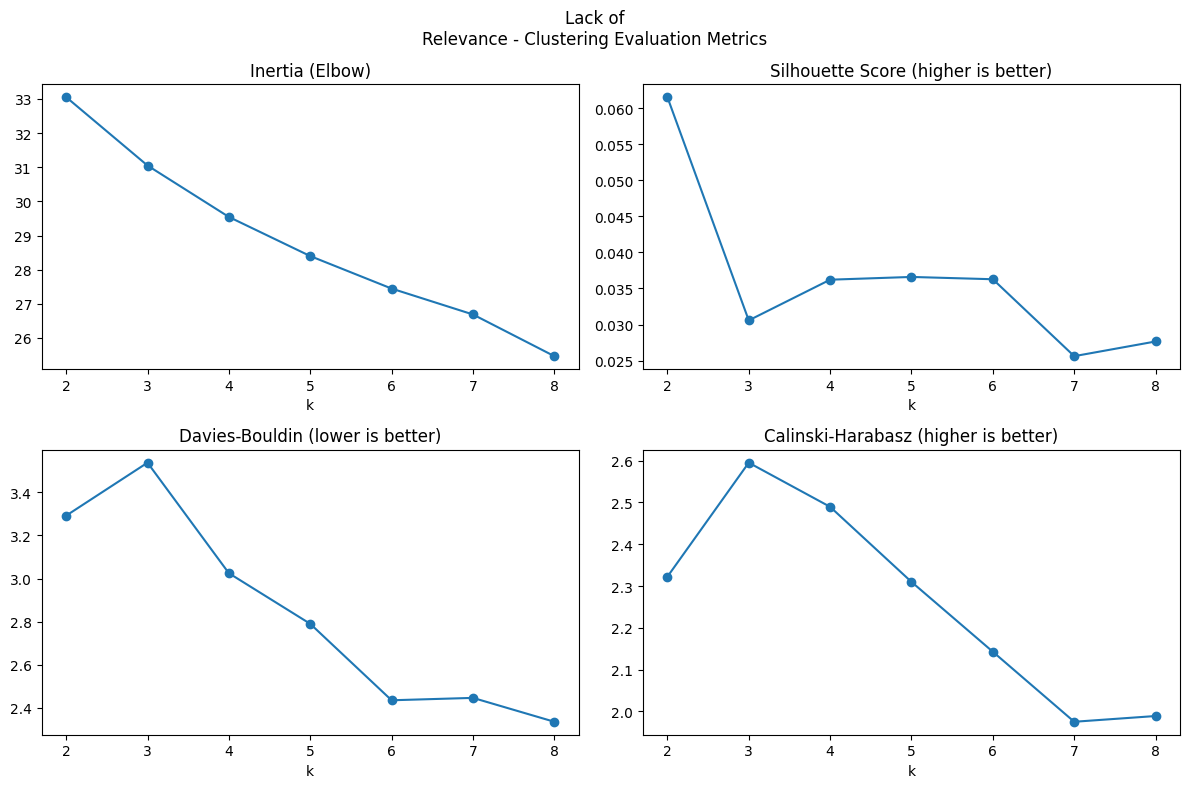

,k,silhouette,davies_bouldin,calinski_harabasz,inertia
0,2,0.061514,3.291985,2.322216,33.053871
1,3,0.030570,3.538104,2.595232,31.050339
2,4,0.036210,3.024641,2.489543,29.544621
3,5,0.036591,2.789464,2.309859,28.398678
4,6,0.036272,2.434244,2.142651,27.447165
5,7,0.025613,2.445335,1.975029,26.688931
6,8,0.027648,2.334367,1.988790,25.468014


In [139]:
evaluate_k(platform_df, "Lack of\nRelevance")
evaluate_k(no_platform_df, "Lack of\nRelevance")

# SCAM

(20, 14)

===== Possibility
of Scam =====
   k  silhouette  davies_bouldin  calinski_harabasz    inertia
0  2    0.086243        2.067659           2.372983  11.423656
1  3    0.104204        1.810053           2.587294   9.912441
2  4    0.104874        1.495522           2.375813   8.944985
3  5    0.108858        1.465817           2.335443   7.967577
4  6    0.125408        1.355083           2.416914   6.939554
5  7    0.070138        1.438769           2.112499   6.546666
6  8    0.033744        1.331469           1.827618   6.257973


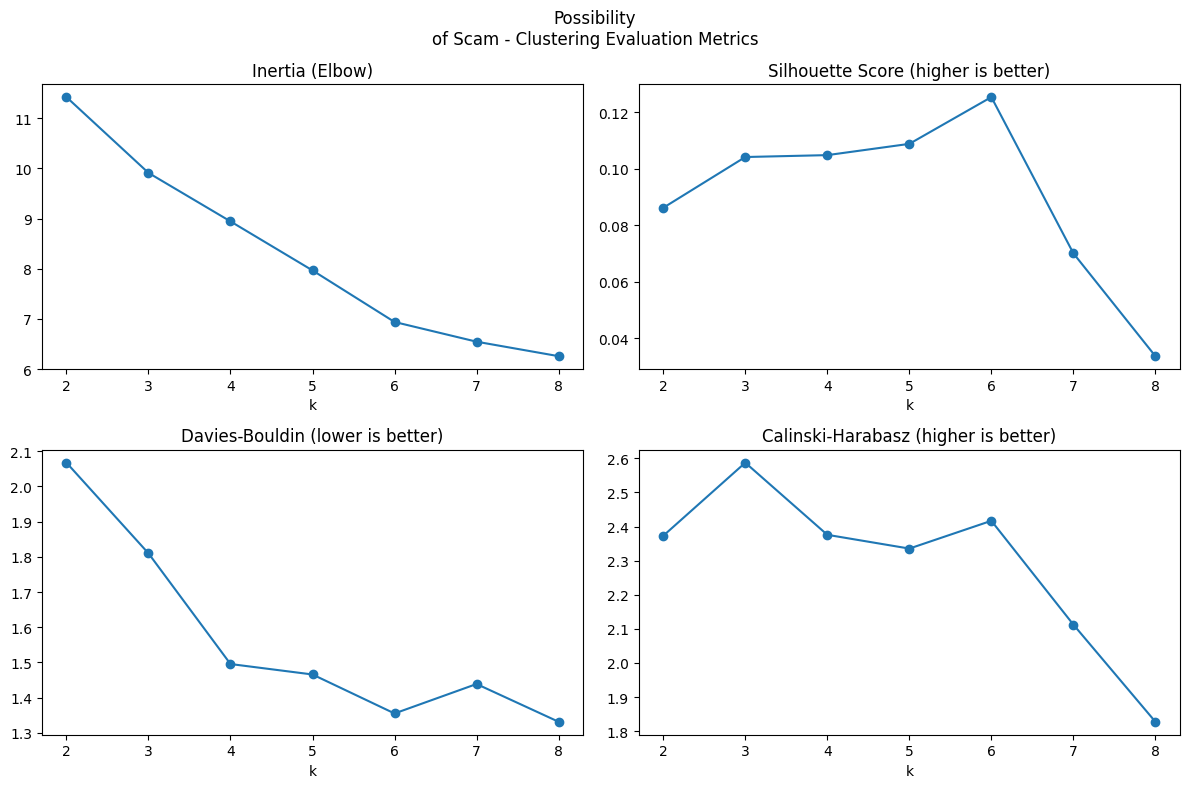

(23, 14)

===== Possibility
of Scam =====
   k  silhouette  davies_bouldin  calinski_harabasz    inertia
0  2    0.034456        2.700017           1.502852  16.514328
1  3    0.060706        2.368649           2.091149  14.635636
2  4    0.062807        1.896872           1.919249  13.580685
3  5    0.062434        1.764634           1.913553  12.416323
4  6    0.082380        1.676548           2.026669  11.087274
5  7    0.048918        1.724083           1.916535  10.296247
6  8    0.058677        1.371367           1.871065   9.447206


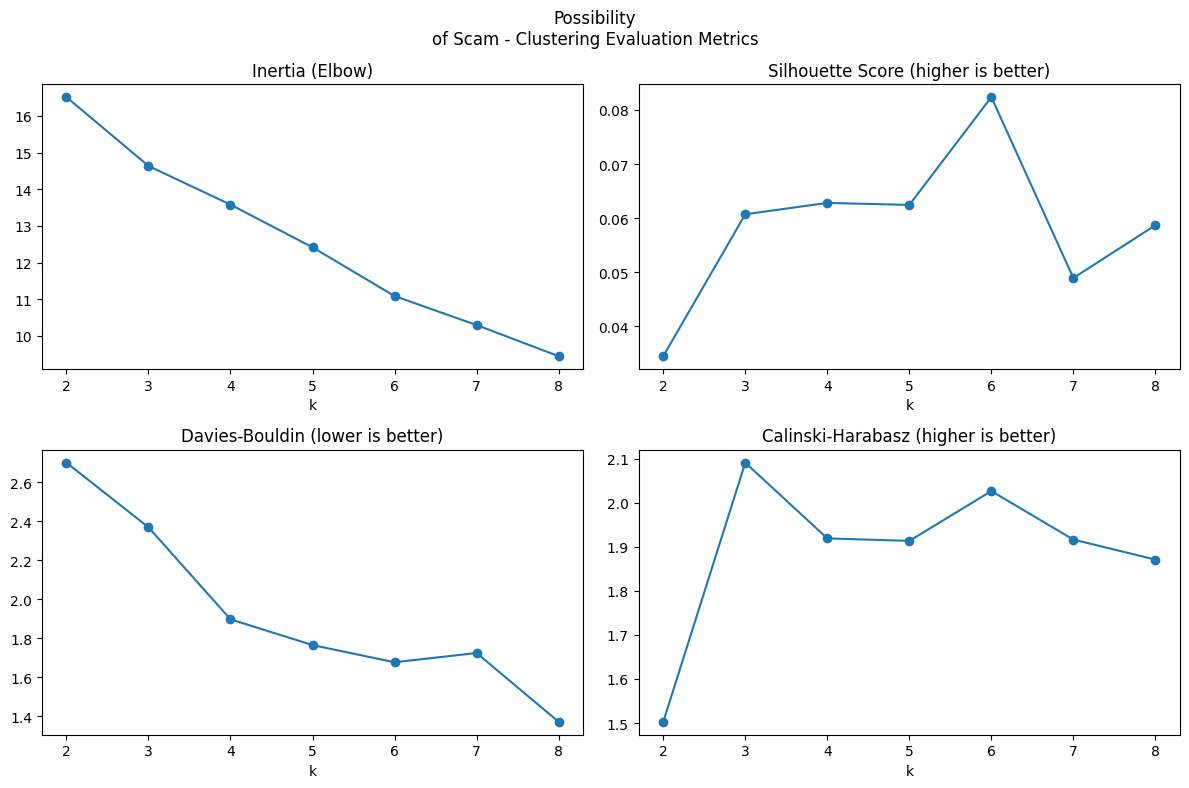

,k,silhouette,davies_bouldin,calinski_harabasz,inertia
0,2,0.034456,2.700017,1.502852,16.514328
1,3,0.060706,2.368649,2.091149,14.635636
2,4,0.062807,1.896872,1.919249,13.580685
3,5,0.062434,1.764634,1.913553,12.416323
4,6,0.082380,1.676548,2.026669,11.087274
5,7,0.048918,1.724083,1.916535,10.296247
6,8,0.058677,1.371367,1.871065,9.447206


In [140]:
evaluate_k(platform_df, "Possibility\nof Scam")
evaluate_k(no_platform_df, "Possibility\nof Scam")

# Visibility


(10, 14)

===== Lack of
Visibility =====
   k  silhouette  davies_bouldin  calinski_harabasz   inertia
0  2    0.075525        1.481052           1.613080  5.217915
1  3    0.129011        1.513388           2.204093  3.847255
2  4    0.105803        1.129399           1.896675  3.218143
3  5    0.058951        0.911070           1.620953  2.729943
4  6    0.083848        0.757272           1.864181  1.882763
5  7    0.047624        0.698089           1.837168  1.341373
6  8    0.056064        0.544979           2.138448  0.738992


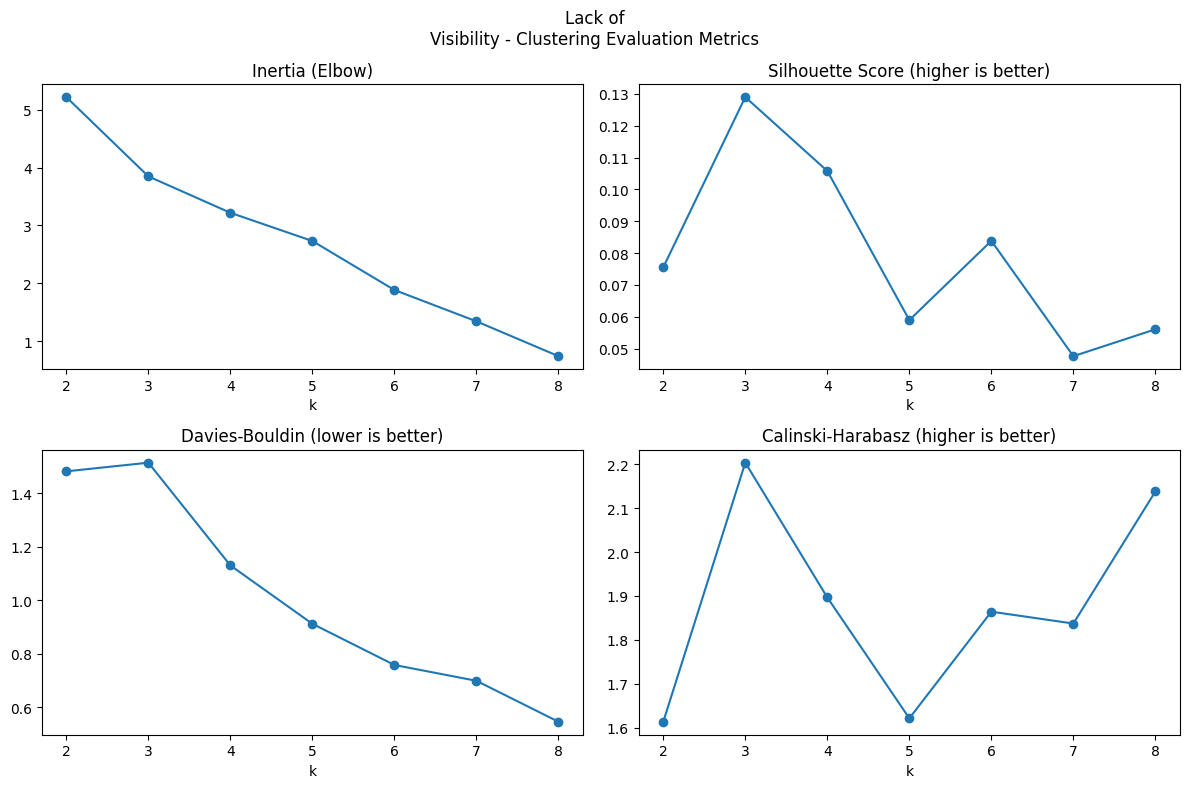

(28, 14)

===== Lack of
Visibility =====
   k  silhouette  davies_bouldin  calinski_harabasz    inertia
0  2    0.163254        1.933618           6.738109  15.845499
1  3    0.131041        1.750754           4.313906  14.832951
2  4    0.074738        2.055959           3.608941  13.749392
3  5    0.080369        1.952364           3.440664  12.482657
4  6    0.050812        1.741581           2.901266  12.023769
5  7    0.046087        1.805180           2.724341  11.219172
6  8    0.070390        1.638922           2.877725   9.940187


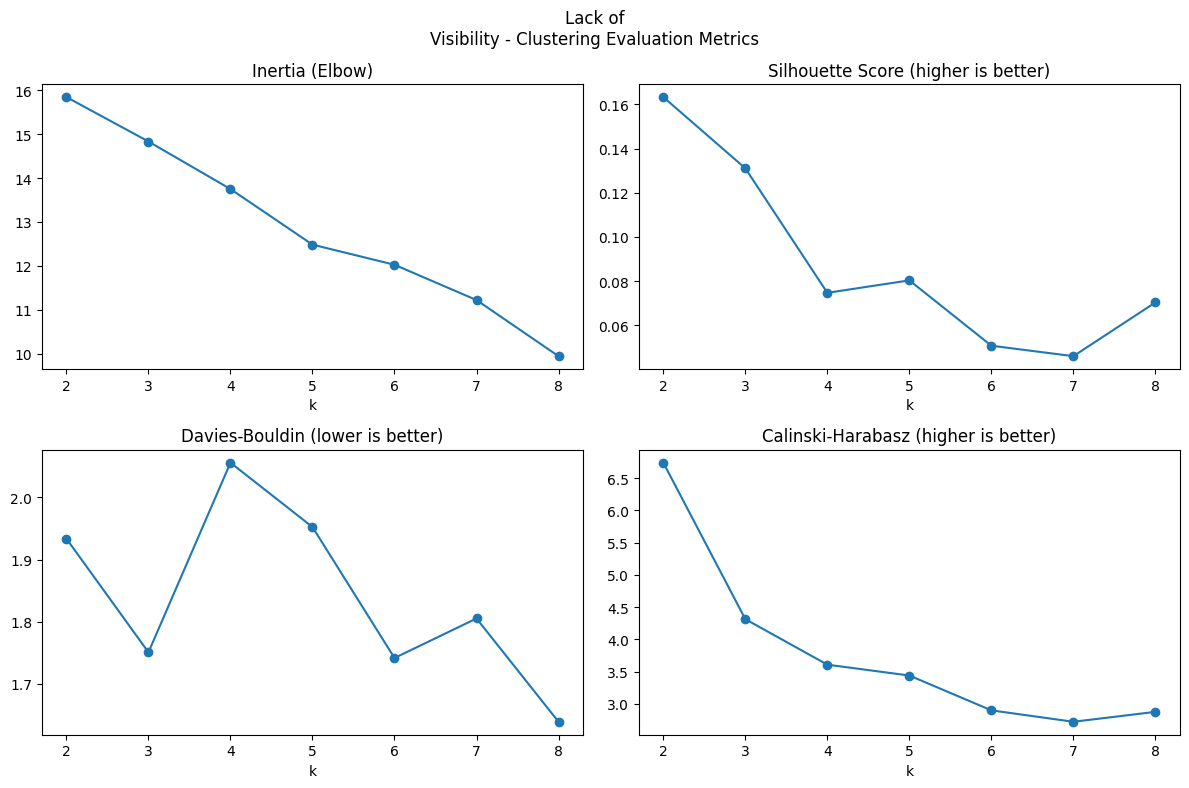

,k,silhouette,davies_bouldin,calinski_harabasz,inertia
0,2,0.163254,1.933618,6.738109,15.845499
1,3,0.131041,1.750754,4.313906,14.832951
2,4,0.074738,2.055959,3.608941,13.749392
3,5,0.080369,1.952364,3.440664,12.482657
4,6,0.050812,1.741581,2.901266,12.023769
5,7,0.046087,1.805180,2.724341,11.219172
6,8,0.070390,1.638922,2.877725,9.940187


In [141]:
evaluate_k(platform_df, "Lack of\nVisibility")
evaluate_k(no_platform_df, "Lack of\nVisibility")

## Other

(2, 14)
Not enough data for Other
(20, 14)

===== Other =====
   k  silhouette  davies_bouldin  calinski_harabasz    inertia
0  2    0.076506        2.272180           1.652633  13.636771
1  3    0.031974        2.588027           1.516278  12.634915
2  4    0.025945        2.133312           1.492227  11.633763
3  5    0.033119        1.777795           1.563146  10.508467
4  6    0.039391        1.569378           1.553725   9.575399
5  7    0.048662        1.585276           1.606090   8.550532
6  8    0.102261        1.185698           2.021561   6.832094


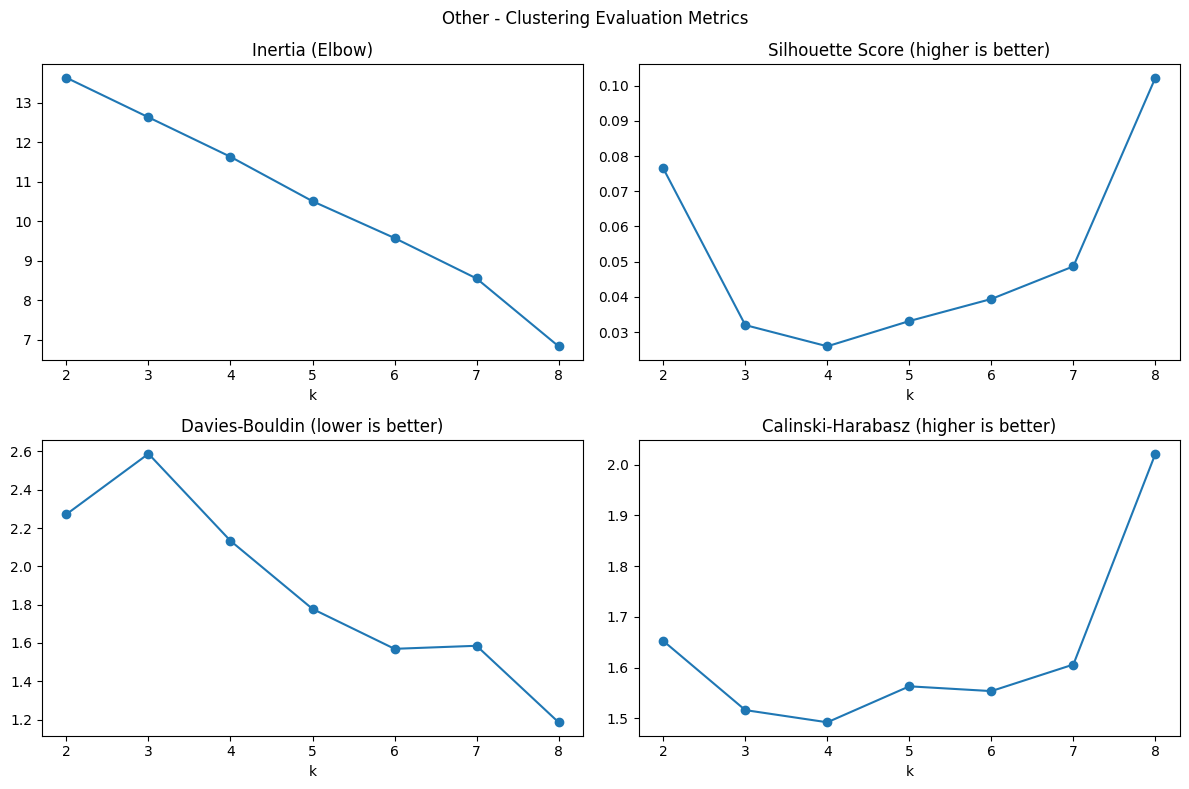

,k,silhouette,davies_bouldin,calinski_harabasz,inertia
0,2,0.076506,2.272180,1.652633,13.636771
1,3,0.031974,2.588027,1.516278,12.634915
2,4,0.025945,2.133312,1.492227,11.633763
3,5,0.033119,1.777795,1.563146,10.508467
4,6,0.039391,1.569378,1.553725,9.575399
5,7,0.048662,1.585276,1.606090,8.550532
6,8,0.102261,1.185698,2.021561,6.832094


In [142]:
evaluate_k(platform_df, "Other")
evaluate_k(no_platform_df, "Other")

## Overseas Experience

(4, 14)
Not enough data for Overseas
Experience
(15, 14)

===== Overseas
Experience =====
   k  silhouette  davies_bouldin  calinski_harabasz   inertia
0  2    0.088319        2.150815           2.392190  8.454288
1  3    0.083761        1.988388           2.208407  7.316890
2  4    0.080995        1.715014           2.040439  6.431165
3  5    0.084486        1.417560           1.901610  5.685421
4  6    0.112502        1.208579           2.090370  4.631436
5  7    0.107872        1.089399           2.012914  3.988548
6  8    0.104040        1.003861           2.027263  3.306617


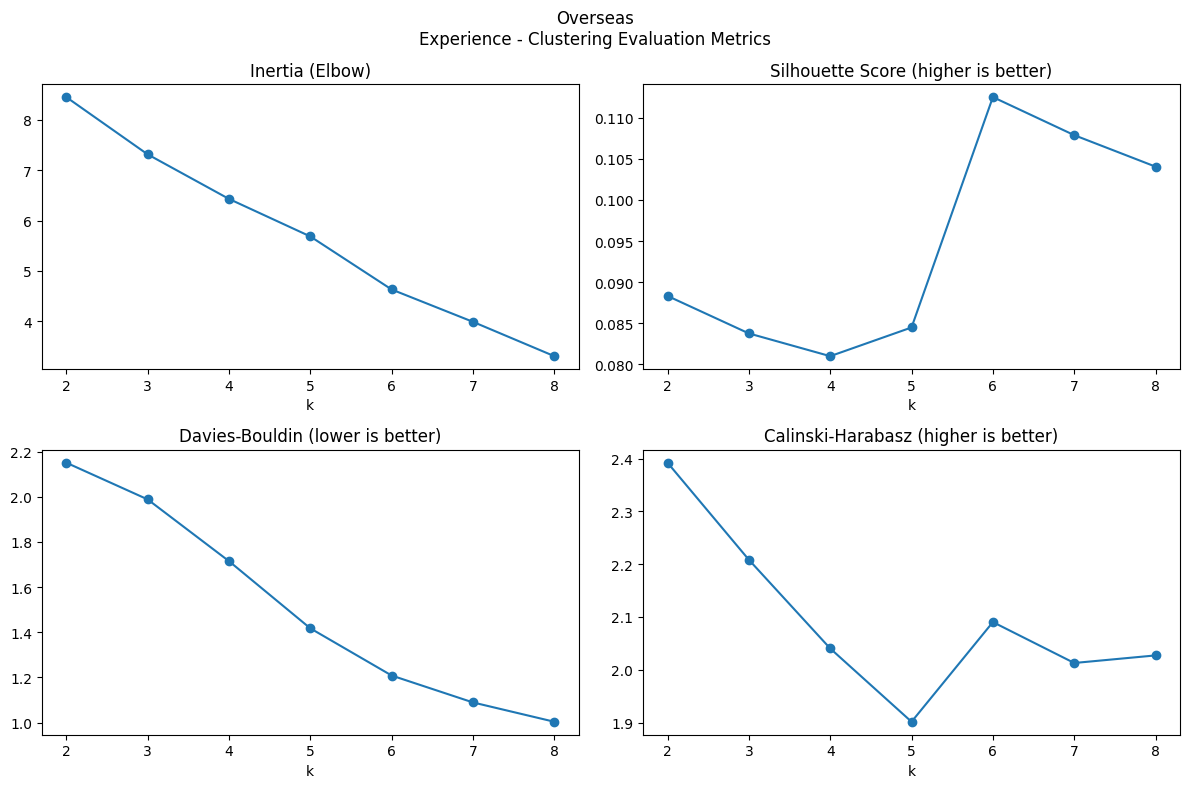

,k,silhouette,davies_bouldin,calinski_harabasz,inertia
0,2,0.088319,2.150815,2.392190,8.454288
1,3,0.083761,1.988388,2.208407,7.316890
2,4,0.080995,1.715014,2.040439,6.431165
3,5,0.084486,1.417560,1.901610,5.685421
4,6,0.112502,1.208579,2.090370,4.631436
5,7,0.107872,1.089399,2.012914,3.988548
6,8,0.104040,1.003861,2.027263,3.306617


In [143]:
evaluate_k(platform_df, "Overseas\nExperience")
evaluate_k(no_platform_df, "Overseas\nExperience")

# Advanced Methods

My plan here was to run K-means clusters on each theme tag and uncover what specific events were occurring. 

In [91]:
def show_cluster_theme(df, theme, k=2):
    subset = df[df["Theme Tag"] == theme].copy()
    texts = subset["Content (English)"].fillna("").tolist()

    # embeddings
    if len(texts) < 10:
        print(f"Not enough data for {theme}")
        return

    embeddings = model.encode(texts, show_progress_bar=False)
    embeddings = normalize(embeddings)

    # clustering
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(embeddings)

    subset["Sub_theme"] = labels

    print(f"\n===== {theme} =====")

    # print ALL content per cluster
    for i in range(k):
        print(f"\n===== Sub-theme {i} =====\n")

        cluster_texts = subset[subset["Sub_theme"] == i]["Content (English)"]
        display(
            subset[subset["Sub_theme"] == i][
                ["Content (Full Text)", "Sub_theme"]
            ].reset_index(drop=True)
        )

    return subset

## UX

In [ ]:
platform_ux_df = show_cluster_theme(platform_df, "Confusing\nUX", k=5)
no_platform_ux_df = show_cluster_theme(no_platform_df, "Confusing\nUX", k=3)


===== Job Search
Burnout =====

===== Sub-theme 0 =====



,Content (Full Text),Sub_theme
0,I don't know what to do with this offer. I kno...,0



===== Sub-theme 1 =====



,Content (Full Text),Sub_theme
0,Hey everyone. I have been unemployed since Apr...,1
1,I know this is long but I wish someone had pos...,1



===== Sub-theme 2 =====



...

,Content (Full Text),Sub_theme
0,"mahirap maghanap ngayon, pero kaya yan OP. goo...",0
1,School is done and now you experience the real...,0
2,"lmao, this is sadly a reality. welcome to the ...",0
3,"Unless you signed on the doted line, keep it m...",0
4,Please dont end your life. I hope you can get ...,0



===== Sub-theme 1 =====



,Content (Full Text),Sub_theme
0,"it could really take a long time, i know. it i...",1
1,I've been looking for a job almost 2 weeks na ...,1
2,I spent 6 months actively looking for my first...,1
3,"Man, I’m so nervous kasi I feel the same and t...",1
4,Not to mention the hope and excitement you get...,1
5,I feel you. It took me a year and a half and h...,1
6,whoa i admire your tenacity OP. ako kinain na ...,1
7,I feel you OP. I found a part-time job pero fe...,1
8,"I feel you deeply OP, since March, I'm still t...",1
9,Tuloy ang buhay O.P. \nApply lang ng apply. R...,1



===== Sub-theme 2 =====



,Content (Full Text),Sub_theme
0,apply lang ng apply . ako nga 1 year na stop d...,2
1,My partner did that. It was unpleasant for all...,2
2,passed my resig last august without a job offe...,2
3,"My experience was 2017 pa, I resigned na walan...",2
4,Was unemployed for 4 months. Nag pahinga ako k...,2
5,Hi! I got laid off last year December in the h...,2
6,Tinanggal sa trabaho noong 2019 luckily di pa ...,2
7,I never doubted myself when I did this but I h...,2
8,Unemployed for 4 fucking years here. Make it 5...,2
9,I wouldn’t recommend leaving without a job lin...,2


In [93]:
platform_ux_df

,Source Subreddit,Post URL,Post Title,Post or Comment,Content (Full Text),Date Posted,Upvotes / Score,Theme Tag,Platform Mentioned,Philippine Context?,Notable Quote,Intern Notes,Has Platform,Content (English),Sub_theme
219,r/phcareers,https://www.reddit.com/r/phcareers/comments/1n...,Use of LinkedIN Connections to Secure Unposted...,post,Madami akong nababasa dito about difficulty of...,2025-09,1263,Confusing\nUX,LinkedIn,Yes,"Yes, totoo, ako nga na merong 19-years of expe...",NaN,True,I read a lot here about the difficulty of secu...,2
228,r/phcareers,https://www.reddit.com/r/phcareers/comments/1l...,Am I the problem or is the PH job market reall...,post,"Been applying for jobs ever since I (F, 24) wa...",2025-06,227,Confusing\nUX,"Indeed, Jobstreet, Kalibrr",Yes,"Been applying for jobs ever since I (F, 24) wa...",NaN,True,"Been applying for jobs ever since I (F, 24) wa...",0
243,r/phcareers,https://www.reddit.com/r/phcareers/comments/1o...,Job Hunting 2025: May pag-asa pa ba?,post,"Hello! In average, or based sa experience niny...",2025-11,89,Confusing\nUX,"LinkedIn, Indeed, Jobstreet, Kalibrr",Yes,"LinkedIn, JobStreet, Indeed, Kalibrr, Jora, Pr...",NaN,True,"Hello! On average, or based on your experience...",3
266,r/phcareers,https://www.reddit.com/r/phcareers/comments/1q...,Job hunting at higher levels (Senior Manager/D...,post,I have this irrational fear that I’ll eventual...,2026-01,18,Confusing\nUX,LinkedIn,Yes,I've beefed up my emergency fund specifically ...,NaN,True,I have this irrational fear that I’ll eventual...,2
269,r/phcareers,https://www.reddit.com/r/phcareers/comments/1q...,Possible employer red flag or not? (pre-interv...,post,I applied for this company through indeed beca...,2026-02,14,Confusing\nUX,"LinkedIn, Indeed",Yes,The next day I woke up around 10am due to head...,NaN,True,I applied for this company through indeed beca...,2
276,r/phcareers,https://www.reddit.com/r/phcareers/comments/1k...,Can I back out after akong i-endorse for a fin...,post,"(Not sure if it's the right flair, I'm sorry)\...",2025-04,11,Confusing\nUX,LinkedIn,Yes,Sinabihan nila ako na they'll update me sa sta...,NaN,True,"(Not sure if it's the right flair, I'm sorry)\...",0
287,r/phcareers,https://www.reddit.com/r/phcareers/comments/1m...,Experience with unresponsive NGO employers?,post,What's your honest take on organizations who d...,2025-08,7,Confusing\nUX,LinkedIn,Yes,"(To our HR people, kindly enlighten us if this...",NaN,True,What's your honest take on organizations who d...,3
297,r/phcareers,https://www.reddit.com/r/phcareers/comments/1n...,"Hiring Managers/HR/TAs, what are your honest t...",post,Out of the job searches I've had in more than ...,2025-09,3,Confusing\nUX,LinkedIn,Yes,Been leveraging Linkedin to connect with hirin...,NaN,True,Out of the job searches I've had in more than ...,3
302,r/phcareers,https://www.reddit.com/r/phcareers/comments/1m...,New to job hunting. Is this normal?,post,Posted through my linkedin profile that I'm op...,2025-08,2,Confusing\nUX,LinkedIn,Yes,"I messaged him, thanked him for reaching out a...",NaN,True,Posted through my linkedin profile that I'm op...,1
378,r/recruitinghell,https://www.reddit.com/r/recruitinghell/commen...,"Job Search After 4,000 Applications",post,"2,537 applications were from Handshake, 1,284 ...",2025-05,8565,Confusing\nUX,"LinkedIn, Indeed",No,Place a limit on how much time you’ll spend ap...,"4000 applications: 2537 Handshake, 1284 Linked...",True,"2,537 applications were from Handshake, 1,284 ...",0


In [94]:
print_notable_quotes(platform_ux_df)

NOTABLE QUOTES FOR SUB-THEME 2 BELOW
--------------------------------------------------------------------------------

Yes, totoo, ako nga na merong 19-years of experience sa IT industry [umabot ng 9-months](https://www.reddit.com/r/phcareers/comments/1lk6j2q/got_a_new_job_after_9months_of_search/) before I secured my

--------------------

I've beefed up my emergency fund specifically for joblessness to last a full year to prep for this 

Tbh, I think I’ve done most of the right things but ung fear is still there especially thinking abo

--------------------

The next day I woke up around 10am due to headache that's when I noticed na nagset na pala agad ng interview yung company na yun at that day, in person, at 9am.

--------------------

**#9 Salary transparency?**  
Jobs now pay “competitive compensation,” which is code for “you’ll find out after you’ve emotionally committed and moved across the country.”

**#10 Networking is easy wh

--------------------

NOTABLE QUOTES FOR SUB-TH

## GHOSTING

In [ ]:
show_cluster_theme(combined_df, "Ghosting", k=3)


===== Ghosting =====

===== Sub-theme 0 =====

1. I came from a top school (but not from the big 4) with student-org expriences.It's the same thing naman, ang hirap. I applied for 11 companies and they all ghosted me. It took me 3 weeks to officially started my OJT.

2. Happened to me 2 yrs ago

I Applied, did the intial and final interview + exams. Signed a bunch of bullshit papers and told me that they were gonna call and they did after 1 FCKN WEEK but the hr said that the position was full and so I have to go to a different branch and gonna take the process all over again like WTF?! 

Idk if this is legal or illegal I just moved on and applied to a different company

3. Got a job offer in the past and even signed a contract then the employer ghosted me lmao. I feel you.

I think in your situation they were just trying to be nice but no plans on hiring you. Just try to find another job.

4. I blacklist companies with disrespectful HR practices like ghosting after HOURS of process sp

## EMOTIONAL

In [ ]:
show_cluster_theme(combined_df, "Job Search\nBurnout", k=2)


===== Job Search
Burnout =====

===== Sub-theme 0 =====

1. I'm a fresh grad with latin honors, a license, and a certification.

I've applied to 50+ jobs on Indeed and messaged the companies that I could message. Eight employers did not select me, and 3 viewed my application although it's been days and I have not heard from them yet. I've had a phone interview once but it was to inform me that they needed someone with experience and they would recommend me to a position similar to my internship experience. Another company emailed me about whether I had previous projects or contracts but they haven't replied to me, too. It's frustrating because since I've been busy studying for my license and certification, most of my blockmates have found jobs with 20k+ salaries even before having the license and certification that I have. I thought it would make me stand out to employers but I guess not, I'm not sure how I will be hired as a fresh grad if they always want someone with experience.

I'